# EDA — Online Shoppers Purchasing Intention

Análise exploratória do dataset que alimenta o pipeline. O objetivo aqui é
**justificar as decisões de engenharia** que estão no código, não repetir o
treino: por que PR-AUC em vez de accuracy, por que `OperatingSystems` é
tratado como categoria, e quais features carregam o sinal.

> Rode `poetry run dvc repro` (ou ao menos o estágio `download`) antes deste
> notebook — ele lê o CSV versionado pelo DVC.

In [1]:
# O notebook vive em notebooks/, mas os imports são relativos à raiz do
# projeto — este bootstrap deixa `import src...` funcionar em qualquer kernel.
import os
import sys

RAIZ = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(RAIZ)
sys.path.insert(0, RAIZ)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET, get_settings
from src.data.loader import load_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

df = load_raw(get_settings().raw_data_path)
df.shape

(12330, 18)

## 1. Estrutura e qualidade dos dados

In [3]:
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "valores_unicos": df.nunique(),
})

,dtype,nulos,valores_unicos
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


**Zero valores ausentes.** O `SimpleImputer` no pipeline é uma rede de
segurança para dados de inferência, não uma necessidade do treino.

## 2. O desbalanceamento — e por que ele define a métrica

Taxa de conversão: 15.47%
Accuracy de um modelo que sempre responde 'não compra': 84.53%


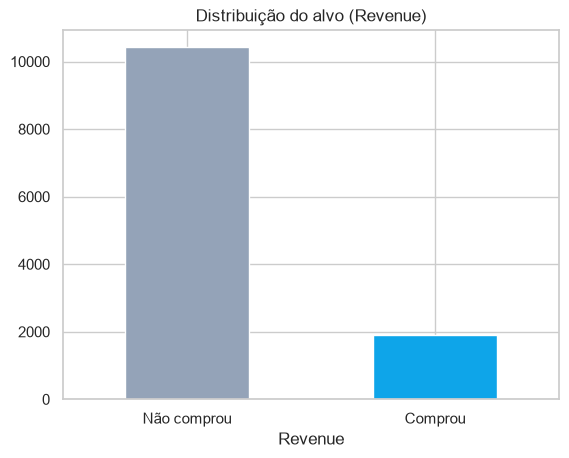

In [4]:
conversao = df[TARGET].mean()
print(f"Taxa de conversão: {conversao:.2%}")
print(f"Accuracy de um modelo que sempre responde 'não compra': {1 - conversao:.2%}")

ax = df[TARGET].value_counts().plot(kind="bar", color=["#94a3b8", "#0ea5e9"])
ax.set_title("Distribuição do alvo (Revenue)")
ax.set_xticklabels(["Não comprou", "Comprou"], rotation=0)
plt.show()

> Este gráfico é o argumento central do projeto: **um classificador trivial já
> acerta 84,5%**. Por isso a métrica de seleção em `params.yaml` é a `pr_auc`,
> cujo piso é a própria taxa de positivos (0,155) — e não a accuracy.

## 3. Colunas numéricas que são, na verdade, categorias

In [5]:
codigos = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[codigos].describe().T[["mean", "min", "max"]]

,mean,min,max
OperatingSystems,2.124006,1.0,8.0
Browser,2.357097,1.0,13.0
Region,3.147364,1.0,9.0
TrafficType,4.069586,1.0,20.0


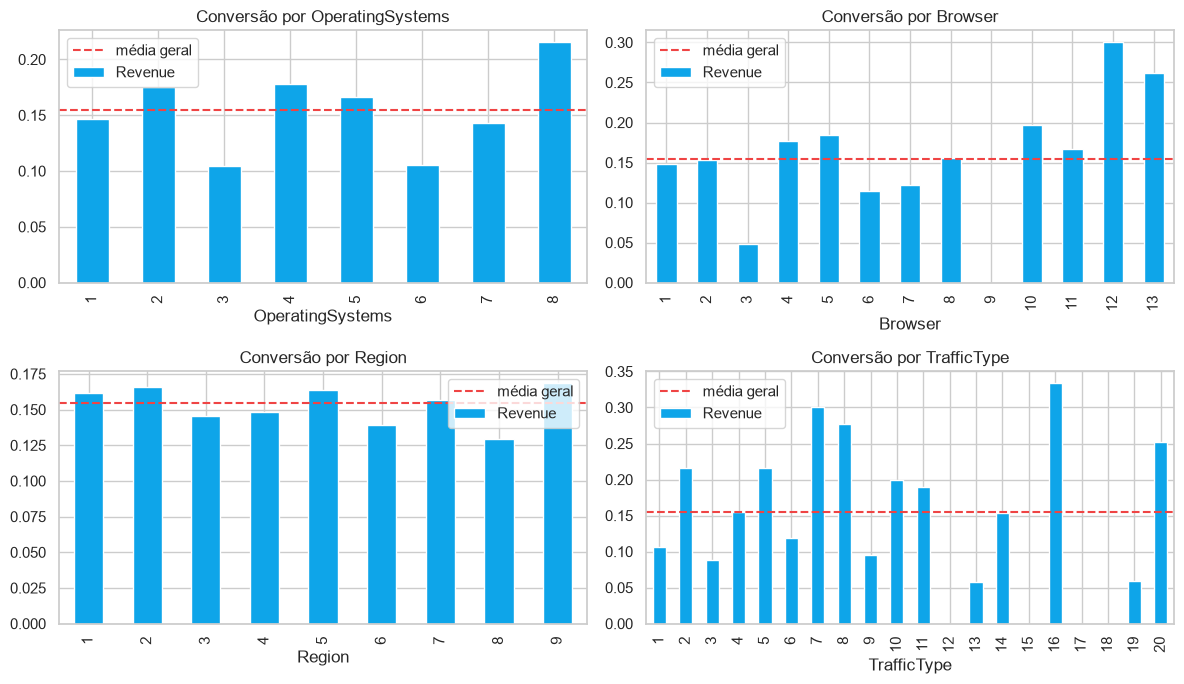

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, coluna in zip(axes.ravel(), codigos):
    taxa = df.groupby(coluna)[TARGET].mean().sort_index()
    taxa.plot(kind="bar", ax=ax, color="#0ea5e9")
    ax.axhline(conversao, color="#ef4444", linestyle="--", label="média geral")
    ax.set_title(f"Conversão por {coluna}")
    ax.legend()
plt.tight_layout()
plt.show()

A relação com a conversão **não é monotônica**: o navegador 13 não é "melhor"
que o 2 em nenhuma escala. Tratar esses códigos como números faria o
`StandardScaler` inventar uma ordem inexistente — por isso `src/config.py`
os lista em `CODE_LIKE_FEATURES` e o loader os converte para `str` antes do
One-Hot Encoding.

## 4. Quais features carregam o sinal

In [7]:
correlacoes = (
    df[NUMERIC_FEATURES]
    .assign(**{TARGET: df[TARGET].astype(int)})
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)
correlacoes.to_frame("correlacao_com_revenue")

,correlacao_com_revenue
PageValues,0.492569
ExitRates,-0.207071
ProductRelated,0.158538
ProductRelated_Duration,0.152373
BounceRates,-0.150673
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
SpecialDay,-0.082305
Informational_Duration,0.070345


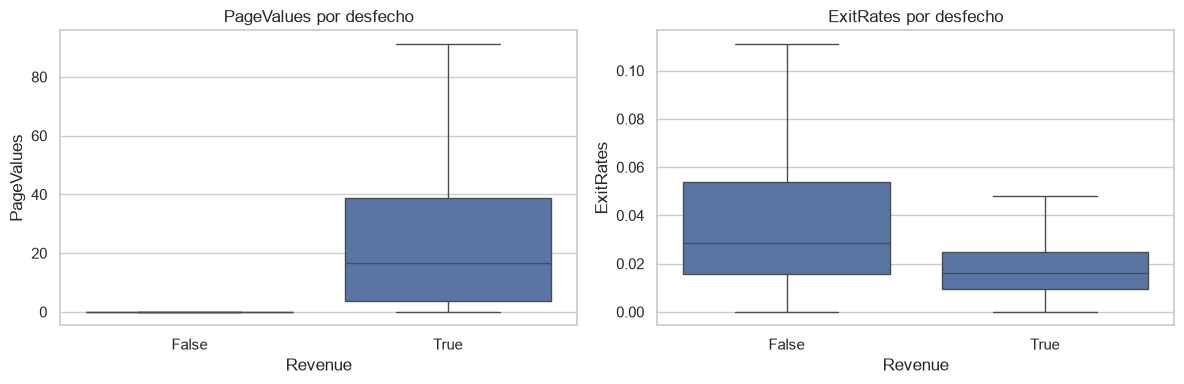

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x=TARGET, y="PageValues", ax=axes[0], showfliers=False)
axes[0].set_title("PageValues por desfecho")
sns.boxplot(data=df, x=TARGET, y="ExitRates", ax=axes[1], showfliers=False)
axes[1].set_title("ExitRates por desfecho")
plt.tight_layout()
plt.show()

`PageValues` domina o sinal com folga. Isso é uma **limitação de produção**,
não só uma curiosidade: a feature vem da camada de analytics do site e precisa
estar disponível em tempo de inferência — está registrado como limitação em
`docs/model_card.md`.

## 5. Sazonalidade e perfil do visitante

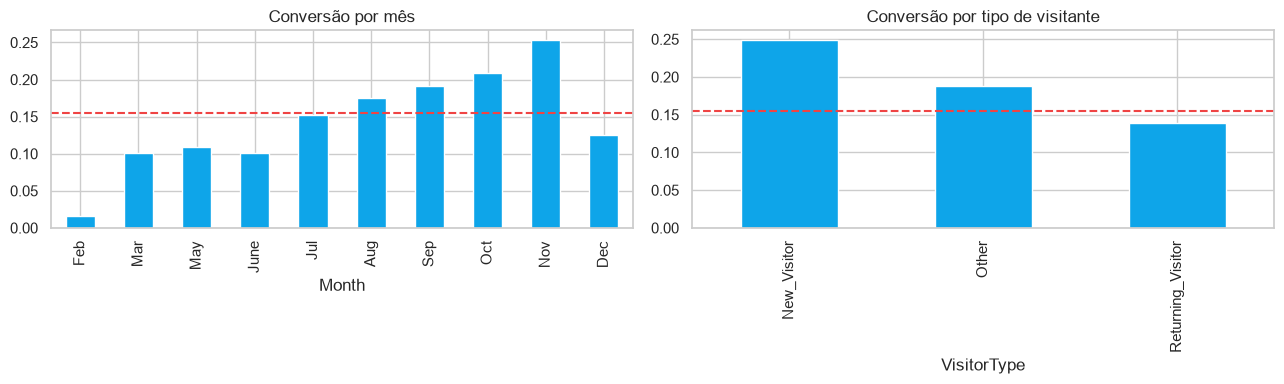

In [9]:
ordem_meses = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

taxa_mes = df.groupby("Month")[TARGET].mean().reindex(ordem_meses)
taxa_mes.plot(kind="bar", ax=axes[0], color="#0ea5e9")
axes[0].axhline(conversao, color="#ef4444", linestyle="--")
axes[0].set_title("Conversão por mês")

df.groupby("VisitorType")[TARGET].mean().plot(kind="bar", ax=axes[1], color="#0ea5e9")
axes[1].axhline(conversao, color="#ef4444", linestyle="--")
axes[1].set_title("Conversão por tipo de visitante")
plt.tight_layout()
plt.show()

Novembro concentra a conversão (Black Friday) — o dataset não cobre janeiro e
abril. Como o split é **aleatório e estratificado**, e não temporal, o modelo
vê todos os meses no treino; uma operação real precisaria de validação
temporal para medir generalização para períodos futuros.

## Conclusões que viraram código

| Observação | Onde está implementada |
|---|---|
| 15,5% de positivos tornam a accuracy enganosa | `params.yaml` → `selection_metric: pr_auc` |
| `DummyClassifier` como piso de comparação | `params.yaml` → `train.models` |
| Códigos numéricos não são grandezas | `src/config.py` → `CODE_LIKE_FEATURES` |
| Categorias novas podem aparecer na inferência | `OneHotEncoder(handle_unknown="ignore")` |
| Zero nulos no treino, mas não garantidos na API | `SimpleImputer` no pipeline |
| Falso negativo é venda perdida | `params.yaml` → `evaluate.cost_false_negative` |